# 基础代码

In [1]:
import deepquantum as dq
import numpy as np
import torch

squeezing = [1] * 6
unitary = np.eye(6)
gbs = dq.photonic.GaussianBosonSampling(nmode=6, squeezing=squeezing, unitary=unitary)
gbs()
gbs.draw()  # 画出采样线路

PNRD（光子数可分辨探测器）： 它具有极高的灵敏度和分辨率，能够精确地告诉你：“现在打过来的是 0 个、1 个、2 个还是 n 个光子”。它克服了饱和效应，能输出具体的光子计数。

In [2]:
gbs.detector = 'pnrd'
result = gbs.measure(shots=1024, mcmc=True)
print(result)

Using MCMC method to sample the final states!


chain 5: 100%|██████████████████████████████| 207/207 [00:00<00:00, 2667.35it/s]

{|000000>: 278, |200000>: 319, |220000>: 24, |202000>: 12, |020022>: 32, |200002>: 76, |000222>: 6, |200022>: 9, |002002>: 45, |000022>: 41, |000020>: 116, |222000>: 16, |020002>: 29, |002022>: 21}


阈值探测器

In [3]:
gbs.detector = 'threshold'
result = gbs.measure(shots=1024, mcmc=True)
print(result)

Using MCMC method to sample the final states!


chain 5: 100%|████████████████████████████| 207/207 [00:00<00:00, 153125.38it/s]


{|010011>: 17, |101101>: 8, |000000>: 86, |001000>: 32, |000100>: 29, |010001>: 20, |100010>: 26, |010100>: 25, |001010>: 26, |001001>: 25, |101000>: 19, |010000>: 31, |110100>: 6, |011111>: 6, |000001>: 48, |011000>: 28, |110000>: 39, |001011>: 8, |100101>: 12, |011100>: 11, |100111>: 7, |010110>: 17, |100001>: 44, |001101>: 10, |001111>: 4, |000111>: 12, |101100>: 11, |110010>: 7, |100000>: 34, |011110>: 5, |000011>: 26, |111001>: 8, |010111>: 7, |111010>: 6, |000110>: 31, |110110>: 10, |101011>: 8, |100011>: 10, |111111>: 1, |011001>: 15, |110011>: 11, |111000>: 11, |110001>: 21, |001100>: 20, |101001>: 12, |000010>: 41, |011010>: 10, |100110>: 20, |110101>: 4, |101010>: 10, |111100>: 7, |100100>: 12, |101110>: 8, |101111>: 7, |000101>: 10, |010101>: 3, |111011>: 1, |111101>: 2, |011011>: 8, |011101>: 8, |010010>: 16, |001110>: 4, |110111>: 1, |111110>: 2}


# 图

生成的邻接矩阵：
[[0 0 0 0 0 1]
 [0 0 1 1 1 0]
 [0 1 0 0 1 0]
 [0 1 0 0 0 1]
 [0 1 1 0 0 1]
 [1 0 0 1 1 0]]
----------------------------------------


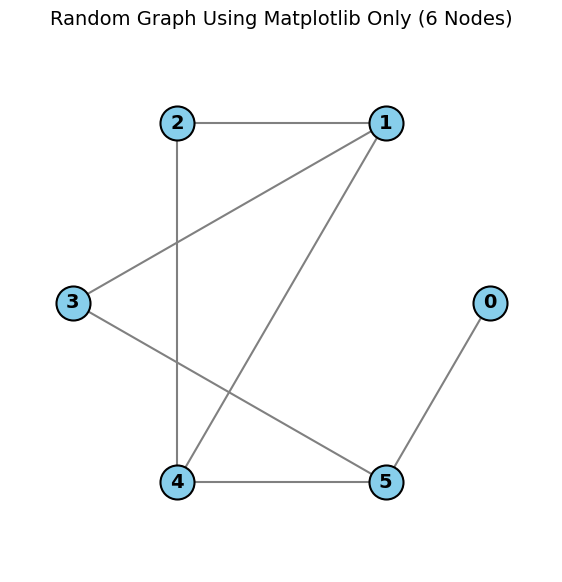

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 参数设置
num_nodes = 6  # 节点数量
probability = 0.5  # 连边概率

# 2. 随机生成邻接矩阵 (0表示无边，1表示有边)
# 这里生成一个无向图的对称矩阵，且对角线为0（无自环）
adj_matrix = np.random.choice(
    [0, 1], size=(num_nodes, num_nodes), p=[1 - probability, probability]
)
adj_matrix = np.triu(adj_matrix, k=1)  # 只保留上三角
adj_matrix = adj_matrix + adj_matrix.T  # 镜像到下三角，形成对称矩阵

print("生成的邻接矩阵：")
print(adj_matrix)
print("-" * 40)

# 3. 手动计算节点的坐标 (让节点均匀分布在一个圆圈上)
# 利用极坐标公式：x = cos(θ), y = sin(θ)
angles = np.linspace(0, 2 * np.pi, num_nodes, endpoint=False)
x_coords = np.cos(angles)
y_coords = np.sin(angles)

# 4. 开始绘图
fig, ax = plt.subplots(figsize=(7, 7))

# 绘制边 (遍历邻接矩阵的上三角，避免重复画线)
for i in range(num_nodes):
    for j in range(i + 1, num_nodes):
        if adj_matrix[i, j] == 1:
            # 连接节点 i 和节点 j 的线
            ax.plot(
                [x_coords[i], x_coords[j]],
                [y_coords[i], y_coords[j]],
                color="gray",
                linestyle="-",
                linewidth=1.5,
                zorder=1,  # 让线处于底层
            )

# 绘制节点
ax.scatter(
    x_coords,
    y_coords,
    s=600,
    color="skyblue",
    edgecolors="black",
    linewidths=1.5,
    zorder=2,  # 让点处于表层
)

# 绘制节点标签（数字编号）
for i in range(num_nodes):
    ax.text(
        x_coords[i],
        y_coords[i],
        str(i),
        color="black",
        fontsize=14,
        fontweight="bold",
        ha="center",
        va="center",
        zorder=3,  # 让文字处于最表层
    )

# 美化界面，隐藏坐标轴和边框
ax.axis("off")
# 稍微扩大一点坐标轴范围，防止边缘的节点显示不全
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
plt.title(f"Random Graph Using Matplotlib Only ({num_nodes} Nodes)", fontsize=14)

# 5. 显示图形
plt.show()

In [5]:
adj_matrix

array([[0, 0, 0, 0, 0, 1],
       [0, 0, 1, 1, 1, 0],
       [0, 1, 0, 0, 1, 0],
       [0, 1, 0, 0, 0, 1],
       [0, 1, 1, 0, 0, 1],
       [1, 0, 0, 1, 1, 0]])

# 编码

np.allclose 是 NumPy 中用于比较两个数组是否“近似相等”的核心函数。它在数值计算中非常重要，因为由于浮点数精度问题，直接使用 == 比较两个浮点数数组几乎总会返回 False。

In [6]:
def encode_graph_to_unitary(A, c_ratio=0.3):
    """
    Encodes a given adjacency matrix into a unitary matrix suitable for Gaussian Boson Sampling (GBS).

    Args:
        A (np.ndarray):     The adjacency matrix of the graph.
        c_ratio (float):    The ratio of the scaling factor c to its maximum theoretical upper bound. 
                            Must be within the range (0, 1). Defaults to 0.9 for safety.

    Returns:
        T (np.ndarray):     The linear optical network matrix (a unitary matrix).
        r (np.ndarray):     A list of physical photon squeezing coefficients for each mode.
    """

    # Ensure the adjacency matrix is symmetric and has zeros on the diagonal
    assert np.allclose(A, A.T), "Adjacency matrix must be symmetric"
    assert np.all(np.diag(A) == 0), "Adjacency matrix must have zeros on the diagonal"

    W = A @ A.conj().T

    d, U = np.linalg.eigh(W)
    d = np.maximum(d, 0) 

    B = U.conj().T @ A @ U.conj()

    B_diag = np.diag(B)

    phi = np.angle(B_diag)/2.0

    phase = np.diag(np.exp(1j * phi))
    T = U @ phase @ U.conj().T

    sqrt_d = np.sqrt(d)
    max_sqrt_d = np.max(sqrt_d)

    if max_sqrt_d > 1e-9:
        c_max = 1.0 / max_sqrt_d
        c = c_ratio * c_max
    else:
        c = 1.0

    tanh_r = c * sqrt_d
    tanh_r = np.clip(tanh_r, 0, 0.999999)
    r = np.arctanh(tanh_r)
    r = torch.tensor(r, dtype=torch.float32)
    
    return T, r

In [7]:
unitary, squeezing = encode_graph_to_unitary(adj_matrix)

In [8]:
unitary

array([[ 0.46700159+0.53299841j, -0.20307699+0.20307699j,
        -0.05694136+0.05694136j, -0.09500301+0.09500301j,
         0.14334435-0.14334435j,  0.41815708-0.41815708j],
       [-0.20307699+0.20307699j,  0.43743551+0.56256449j,
         0.25422095-0.25422095j,  0.31626612-0.31626612j,
         0.20029704-0.20029704j, -0.00860002+0.00860002j],
       [-0.05694136+0.05694136j,  0.25422095-0.25422095j,
         0.43125248+0.56874752j, -0.17291044+0.17291044j,
         0.37939051-0.37939051j, -0.05973264+0.05973264j],
       [-0.09500301+0.09500301j,  0.31626612-0.31626612j,
        -0.17291044+0.17291044j,  0.72352375+0.27647625j,
        -0.12177782+0.12177782j,  0.21508009-0.21508009j],
       [ 0.14334435-0.14334435j,  0.20029704-0.20029704j,
         0.37939051-0.37939051j, -0.12177782+0.12177782j,
         0.42544374+0.57455626j,  0.15813873-0.15813873j],
       [ 0.41815708-0.41815708j, -0.00860002+0.00860002j,
        -0.05973264+0.05973264j,  0.21508009-0.21508009j,
         

In [9]:
squeezing

tensor([0.0309, 0.0640, 0.1286, 0.1435, 0.2580, 0.3095])

# 实验

In [10]:
gbs = dq.photonic.GaussianBosonSampling(nmode=6, squeezing=squeezing, unitary=unitary)
gbs()
gbs.draw()  # 画出采样线路

In [11]:
gbs.detector = 'pnrd'
result = gbs.measure(shots=1024*2, mcmc=True)
print(result)

Using MCMC method to sample the final states!


chain 5: 100%|██████████████████████████████| 411/411 [00:00<00:00, 8962.23it/s]

{|000000>: 818, |201111>: 1, |000101>: 347, |010010>: 31, |000110>: 59, |000200>: 61, |010100>: 65, |012010>: 13, |001120>: 21, |202020>: 6, |210201>: 4, |111021>: 9, |001001>: 6, |200002>: 5, |200101>: 16, |120100>: 1, |101211>: 4, |100010>: 42, |000112>: 36, |000002>: 91, |001100>: 83, |100001>: 286, |120212>: 1, |100100>: 7, |002020>: 35}


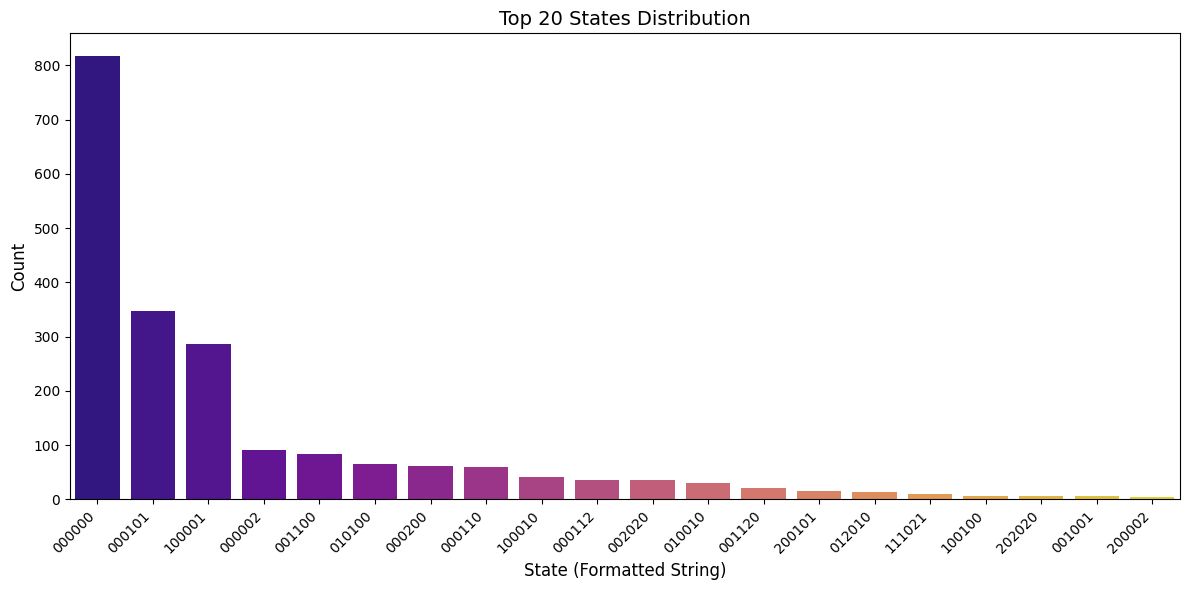

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 假设这是你的原始字典对象
# result = {...} 

# 2. 格式化键
formatted_data = {str(k).strip('|>'): v for k, v in result.items()}

# 3. 装载进 DataFrame 并排序
df = pd.DataFrame(list(formatted_data.items()), columns=['State', 'Count'])
df = df.sort_values(by='Count', ascending=False).reset_index(drop=True)

# 4. 画图（已修复 FutureWarning）
plt.figure(figsize=(12, 6))

sns.barplot(
    x='State', 
    y='Count', 
    data=df.head(20), 
    palette='plasma', 
    hue='State', 
    legend=False
)

plt.xticks(rotation=45, ha='right')
plt.title('Top 20 States Distribution', fontsize=14)
plt.xlabel('State (Formatted String)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()

plt.show()

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 假设你的采样结果存在名为 result 的字典中
# result = { fock_state_obj1: count1, fock_state_obj2: count2, ... }

filtered_result = {}

for fock_state_obj, count in result.items():
    # 1. 直接获取光子数列表，例如 [0, 0, 1, 1, 2, 0]
    photon_list = fock_state_obj.state.tolist()
    
    # 2. 检查是否有冲突：只要有任何一个通道的光子数大于 1，就属于冲突情况，跳过
    if any(x > 1 for x in photon_list):
        continue
        
    # 3. 检查是否是四光子事件：所有通道的光子数总和必须严格等于 4
    if sum(photon_list) == 4:
        # 获取该状态的字符串表示作为画图的标签，例如 "011110"
        # 如果你的 __repr__ 带指针符号，可以用 str(fock_state_obj).replace('|','').replace('>','')
        state_label = "".join(map(str, photon_list))
        filtered_result[state_label] = count

# 4. 按出现频次（Count）从大到小排序
sorted_filtered = sorted(filtered_result.items(), key=lambda x: x[1], reverse=True)

# 如果过滤后有数据，开始绘图
if sorted_filtered:
    states = [item[0] for item in sorted_filtered]
    counts = [item[1] for item in sorted_filtered]
    
    # 5. 绘制条形图
    plt.figure(figsize=(12, 6), dpi=100)
    # 使用渐变色让图表更美观
    colors = sns.color_palette("plasma", len(states))
    
    bars = plt.bar(states, counts, color=colors, edgecolor='black', alpha=0.85)
    
    # 在柱状图上方标注具体数值
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.5, f'{int(height)}', 
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
                 
    plt.title("Filtered 4-Photon States Distribution (No Multi-Photon Conflicts)", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("State (Photon Configuration)", fontsize=12, labelpad=10)
    plt.ylabel("Count", fontsize=12, labelpad=10)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("当前采样结果中没有找到‘无冲突的严格四光子’状态！请检查样本量或实验能量设置。")

当前采样结果中没有找到‘无冲突的严格四光子’状态！请检查样本量或实验能量设置。


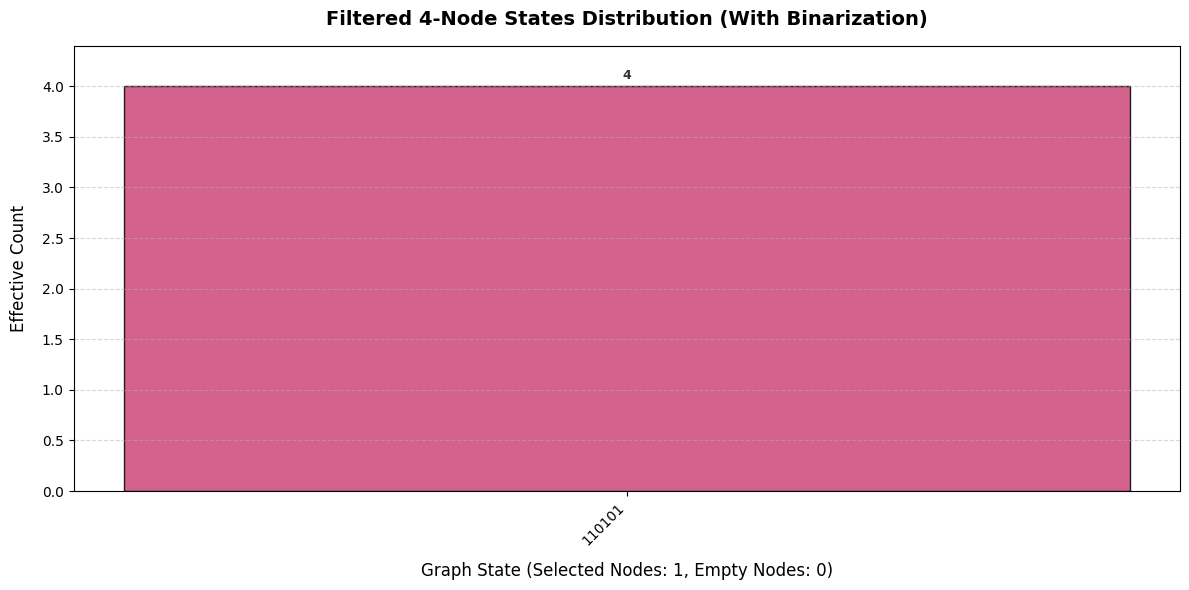

In [14]:
filtered_result = {}

for fock_state_obj, count in result.items():
    # 1. 直接获取底层的光子数列表，例如 [0, 0, 1, 1, 2, 0]
    photon_list = fock_state_obj.state.tolist()
    
    # 2. 过滤掉全 0 的真空态（因为它对寻找子图没有贡献）
    if sum(photon_list) == 0:
        continue
        
    # 3. 【核心步骤】二值化处理：有光子（不管是1个还是2个）就计为 1，没光子计为 0
    # 这样可以完美消除冲突事件带来的负面影响，并恢复它对应的图节点信息
    binary_list = [1 if x > 0 else 0 for x in photon_list]
    
    # 4. 筛选出激活节点数刚好等于 4 的事件（即对应 4 个顶点的子图）
    if sum(binary_list) == 4:
        # 将二值化后的列表转为字符串作为柱状图的横坐标标签，例如 "101101"
        state_label = "".join(map(str, binary_list))
        
        # 累加计数（因为不同的多光子冲突态二值化后可能会合并成同一个图状态）
        filtered_result[state_label] = filtered_result.get(state_label, 0) + count

# 5. 按出现频次（Count）从大到小排序
sorted_filtered = sorted(filtered_result.items(), key=lambda x: x[1], reverse=True)

# 6. 开始绘制美化后的条形图
if sorted_filtered:
    states = [item[0] for item in sorted_filtered]
    counts = [item[1] for item in sorted_filtered]
    
    plt.figure(figsize=(12, 6), dpi=100)
    
    # 使用著名的 plasma 渐变色主题
    colors = sns.color_palette("plasma", len(states))
    
    bars = plt.bar(states, counts, color=colors, edgecolor='black', alpha=0.85, width=0.6)
    
    # 在每个柱子上方标注具体的频次数值
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, height + max(counts)*0.01, f'{int(height)}', 
                 ha='center', va='bottom', fontsize=9, fontweight='bold', color='#333333')
                 
    # 图表细节美化
    plt.title("Filtered 4-Node States Distribution (With Binarization)", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Graph State (Selected Nodes: 1, Empty Nodes: 0)", fontsize=12, labelpad=10)
    plt.ylabel("Effective Count", fontsize=12, labelpad=10)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    # 设置纵轴留白，防止顶部文字被框线挡住
    plt.ylim(0, max(counts) * 1.1)
    
    plt.tight_layout()
    plt.show()
else:
    print("二值化后仍未找到包含 4 个有效节点的状态！请检查原始 result 中的最大光子事件分布。")